In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import joblib

In [13]:
# Load Dataset

final_model = joblib.load("xgboost_sales_model.pkl")

df = pd.read_csv("Modelling_data.csv",low_memory=False)

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

split_date = "2015-06-01"

train_data = df[df["Date"] < split_date]
test_data = df[df["Date"] >= split_date]

In [14]:
X_test = test_data.drop(["Sales", "Date"], axis=1)
y_test = test_data["Sales"]
test_dates = test_data["Date"]

X_test = X_test.apply(pd.to_numeric, errors="coerce")
X_test = X_test.fillna(0)

model_features = final_model.get_booster().feature_names

for col in model_features:
    if col not in X_test.columns:
        X_test[col] = 0

X_test = X_test[model_features]

y_pred = final_model.predict(X_test)

In [15]:
# forecasting data frame

forecast_df = pd.DataFrame({
    "Date": test_dates.values,
    "Actual_Sales": y_test.values,
    "Predicted_Sales": y_pred
})

forecast_df.head()

,Date,Actual_Sales,Predicted_Sales
0,2015-06-01,18082,11759.891602
1,2015-06-01,8074,6509.987793
2,2015-06-01,12736,9924.966797
3,2015-06-01,10536,8229.726562
4,2015-06-01,13798,10292.296875


In [16]:
forecast_daily = forecast_df.groupby("Date")[
    ["Actual_Sales", "Predicted_Sales"]
].sum().reset_index()

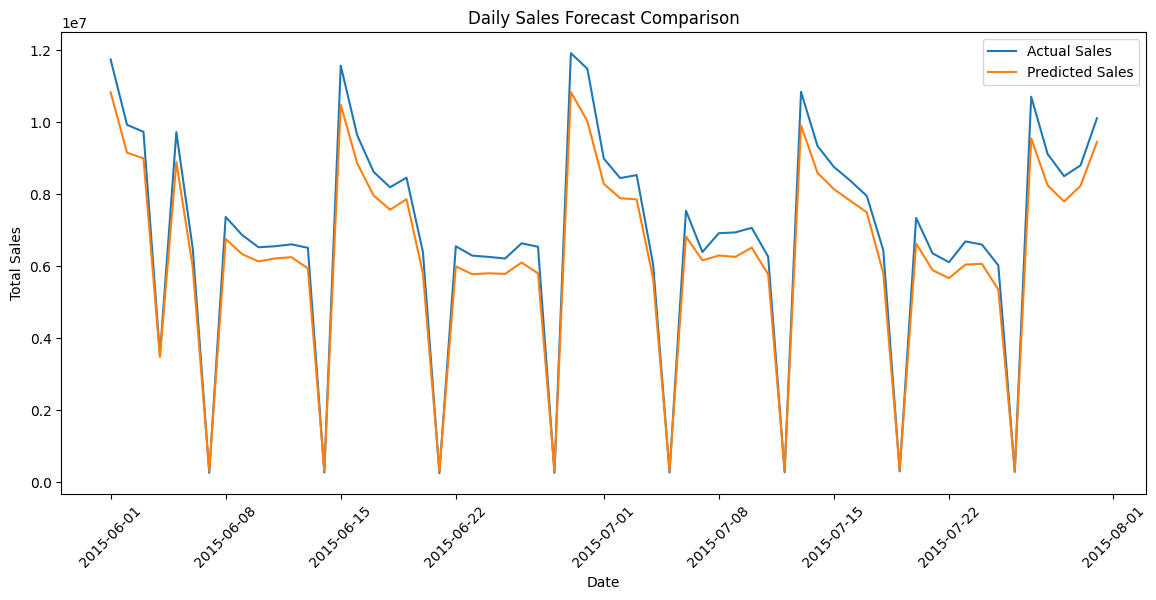

In [17]:
# visual plot of prediction
plt.figure(figsize=(14,6))

plt.plot(
    forecast_daily["Date"],
    forecast_daily["Actual_Sales"],
    label="Actual Sales"
)

plt.plot(
    forecast_daily["Date"],
    forecast_daily["Predicted_Sales"],
    label="Predicted Sales"
)

plt.title("Daily Sales Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.legend()
plt.xticks(rotation=45)

plt.show()

In [18]:
# Forecasting residuals analysis

forecast_daily["Residuals"] = (
    forecast_daily["Actual_Sales"]
    - forecast_daily["Predicted_Sales"]
)


In [19]:
forecast_daily["Residuals"].describe()

count    6.100000e+01
mean     5.473933e+05
std      3.164467e+05
min     -5.764803e+04
25%      4.435475e+05
50%      5.710990e+05
75%      7.041085e+05
max      1.453076e+06
Name: Residuals, dtype: float64

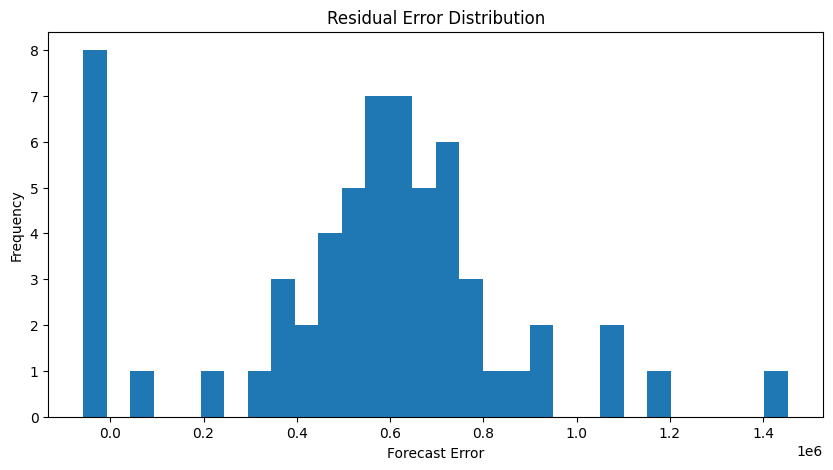

In [20]:
# residuals distribution plot visualy

plt.figure(figsize=(10,5))

plt.hist(
    forecast_daily["Residuals"],
    bins=30
)

plt.title("Residual Error Distribution")
plt.xlabel("Forecast Error")
plt.ylabel("Frequency")

plt.show()


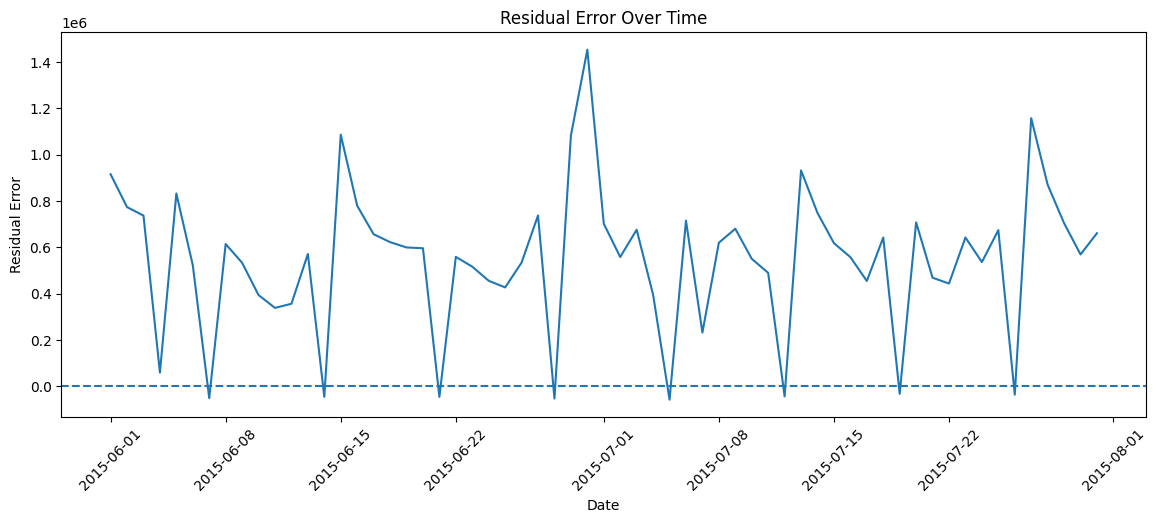

In [21]:
# Residuals plot trend

plt.figure(figsize=(14,5))

plt.plot(
    forecast_daily["Date"],
    forecast_daily["Residuals"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Error Over Time")
plt.xlabel("Date")
plt.ylabel("Residual Error")

plt.xticks(rotation=45)

plt.show()

## __Final Forecasting Analysis Observation__

The Forwcasting analysis demonstrates that the XGBoost model successfully capturated the the temporal sales dynamiics of the Rossmann retail dataset. The predicted sales closed folowed actual sales trends across the forecasting horizon, indicating string generalization capability on unseen future data.
The model effectively captured recurring weekly seasonality patterns. promotional impact, and oprational sales flactualtions.Residual Analysis revelaled relatively stable forecasting errors with moderate underprediction during peak sales periods, which is common in high-volume retail forecasting tasks.
Overall. the forecasting pipeline achieved strong predictive performance and demonstrate the effectiveness of ensembled-based machine learning techniques  for retail sales forecasting applications.